In [1]:
import os
import numpy as np

from astropy.io import fits
import astropy.units as u
import astropy.constants.codata2018 as cst
from astropy.cosmology import LambdaCDM

import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

In [3]:
data_path = "/data/CTA02/kleimenov/EBL_Anisotropy_Static/data/EBL_models/Saldana-Lopez/ebl_saldana21_comoving.fits"
err_path = '/data/CTA02/kleimenov/EBL_Anisotropy_Static/data/EBL_models/Saldana-Lopez/eblerr_saldana21_comoving.fits'

In [4]:
data = fits.open(data_path)
errs = fits.open(err_path)

In [5]:
wvl = data["WAVELENGTH"].data
rsh = data["REDSHIFT"].data
intensity = data["INTENSITY"].data

In [6]:
d_c = cosmo.comoving_distance(rsh).to_value(u.Mpc)
t_lb = (cosmo.lookback_time(rsh) * cst.c).to_value(u.Mpc)
a = cosmo.scale_factor(rsh)

In [7]:
normalizations = np.trapz(intensity, np.log(wvl), axis=1)

ratio = normalizations / normalizations[0]

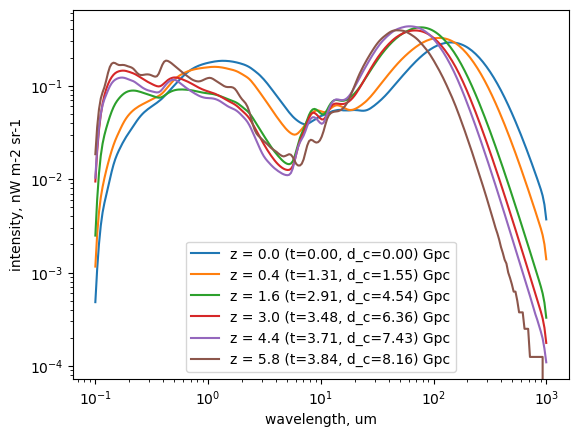

In [8]:
for i in range(0, len(rsh), 7):
    plt.plot(wvl, intensity[i] / normalizations[i],
             label=f"z = {rsh[i]} (t={t_lb[i]/1000:.2f}, d_c={d_c[i]/1000:.2f}) Gpc")
    
plt.xscale('log')
plt.xlabel('wavelength, um')
plt.yscale('log')
plt.ylabel('intensity, nW m-2 sr-1')
plt.legend(ncol=1)
plt.show()

In [9]:
to_derive = ratio * a / a[0]

derivative = (to_derive[1:] - to_derive[:-1]) / (t_lb[1:] - t_lb[:-1])

dc_d = 0.5 * (d_c[1:] + d_c[:-1])
t_lb_d = 0.5 * (t_lb[1:] + t_lb[:-1])

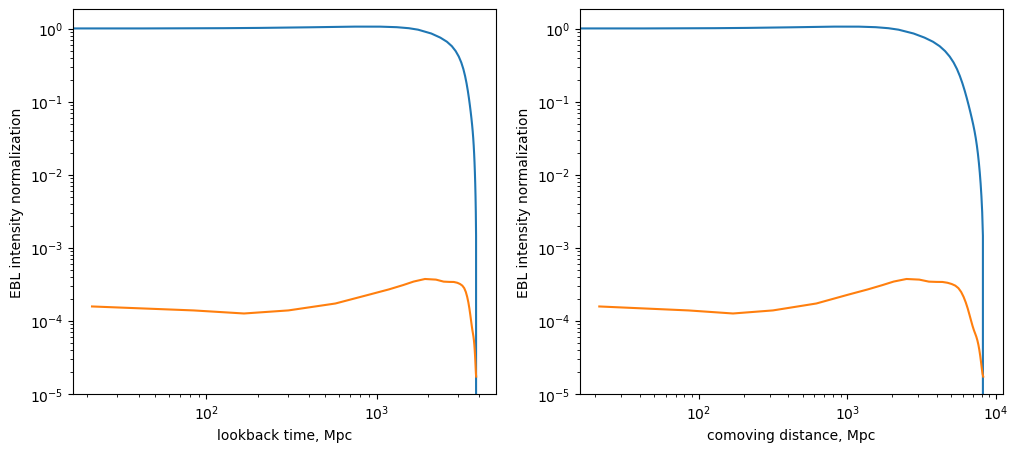

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.plot(t_lb, ratio)
plt.plot(t_lb_d, -derivative)

plt.xlabel('lookback time, Mpc')
plt.xscale('log')

plt.ylabel('EBL intensity normalization')
plt.yscale('log')

plt.subplot(122)

plt.plot(d_c, ratio)
plt.plot(dc_d, -derivative)

plt.xlabel('comoving distance, Mpc')
plt.xscale('log')

plt.ylabel('EBL intensity normalization')
plt.yscale('log')

plt.show()